# Fix 1 (filt2) isolated on the per-SNP AF scatter

**Goal.** Show how Fix 1 alone — dropping singleton k-mers from the EM (`filt2`) — affects the per-SNP AF scatter against hapFIRE.

Fix 1 changes the **h vector** (the founder-mix estimate); it does **not** touch `cn_var`.
Fix 2 (atomization-aware hybrid `cn_var`) is a separate cn_var-level swap that was shown in the main notebook.

We plot three panels:
- **BEFORE** — `h_baseline @ cn_v3`  (current production)
- **Fix 1 only** — `h_filt2 @ cn_v3`  (debiased h, same cn_var)
- **Fix 1 + Fix 2 stacked** — `h_filt2 @ cn_hybrid`  (both fixes)


In [1]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from pathlib import Path
import gzip

ROOT = Path('/global/scratch/users/tbellg/kmate')


/tmp/ipykernel_858995/670296181.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## 1. Load h vectors and per-SNP truth (hapFIRE)

In [2]:
def load_h(d):
    return np.asarray(np.load(d/'SEEDMIX_S1.h_per_chrom.npz', allow_pickle=True)['Chr1']).astype(np.float64)

h_baseline = load_h(ROOT/'results/seedmix_231_v3_perchrom')
h_filt2    = load_h(ROOT/'results/seedmix_231_v3_filt2_chr1')

founders = list(np.asarray(np.load(ROOT/'results/seedmix_231_v3_perchrom/SEEDMIX_S1.h_per_chrom.npz',
                                   allow_pickle=True)['founders']).astype(str))

# hapFIRE per-SNP truth (Chr1 SNPs)
hf_snp = pd.read_csv('/global/scratch/projects/fc_moilab/projects/grenenet-phase1/frequency/hapFIRE_frequencies/seed_mix/s1_snp_frequency.txt',
                     sep='\t', header=None, names=['chrom_n','pos','hf_af'], dtype={'chrom_n':str})
hf_snp = hf_snp[hf_snp.chrom_n=='1'][['pos','hf_af']]
print(f'h_baseline cactus mean: {h_baseline[:80].mean():.5f}')
print(f'h_filt2    cactus mean: {h_filt2[:80].mean():.5f}')
print(f'hapFIRE SNPs (Chr1): {len(hf_snp):,}')


h_baseline cactus mean: 0.00603
h_filt2    cactus mean: 0.00468
hapFIRE SNPs (Chr1): 827,765


## 2. Load v3 `cn_var` (Chr1 SNPs) and the GN hybrid swap

In [3]:
cn3 = sp.load_npz(ROOT/'data/cn_var_231_v3.cn_var.npz').tocsc().astype(np.int8)
mt  = np.load(ROOT/'data/cn_var_231_v3.meta.npz', allow_pickle=True)
v3_founders_full = list(np.asarray(mt['founders']).astype(str))
chrom_cv = np.asarray(mt['chrom']).astype(str)
rl_cv    = np.asarray(mt['ref_len']).astype(np.int32)
al_cv    = np.asarray(mt['alt_len']).astype(np.int32)
pos_cv   = np.asarray(mt['pos']).astype(np.int64)
mask_snp_cv = (chrom_cv=='Chr1') & (rl_cv==1) & (al_cv==1)
chr1_snp_idx = np.where(mask_snp_cv)[0]

# REF/ALT for Chr1 SNPs
v3_ref=[]; v3_alt=[]
with gzip.open(ROOT/'data/cn_var_231_v3.ref_alt.tsv.gz','rt') as fh:
    for line in fh:
        c,p,r,a = line.rstrip('\n').split('\t')
        if c=='Chr1' and len(r)==1 and len(a)==1:
            v3_ref.append(r); v3_alt.append(a)
v3_ref = np.array(v3_ref); v3_alt = np.array(v3_alt)
v3_pos_chr1 = pos_cv[chr1_snp_idx]

# GN (Beagle-imputed) ground-truth GT for the same Chr1 SNPs
gn = np.load(ROOT/'_tmp_grenenet_chr1_snp_gt.npz', allow_pickle=True)
gn_gt_all = gn['gt']; gn_pos = gn['pos']; gn_ref = gn['ref']; gn_alt = gn['alt']
gn_samples = list(gn['samples'])

# Join on (pos,ref,alt)
v3_key = pd.DataFrame({'pos':v3_pos_chr1,'ref':v3_ref,'alt':v3_alt,'v3_idx':np.arange(len(v3_pos_chr1))})
gn_key = pd.DataFrame({'pos':gn_pos,'ref':gn_ref,'alt':gn_alt,'gn_idx':np.arange(len(gn_pos))})
m4 = v3_key.merge(gn_key, on=['pos','ref','alt'])
print(f'Matched (pos,ref,alt) records: {len(m4):,}')

# Per-founder GT matrices on the matched records
v3_cols = chr1_snp_idx[m4['v3_idx'].values]
v3_gt_match = np.asarray(cn3[:, v3_cols].todense()).astype(np.float64)
gn_founder_idx = np.array([gn_samples.index(f) for f in v3_founders_full])
gn_gt_match    = (gn_gt_all[m4['gn_idx'].values][:, gn_founder_idx].T).astype(np.float64)

# hapFIRE AF for the matched records
m4['hf_af'] = m4['pos'].map(dict(zip(hf_snp['pos'], hf_snp['hf_af'])))
hf_af_loc = m4['hf_af'].values
print('v3_gt_match:', v3_gt_match.shape, '  gn_gt_match:', gn_gt_match.shape)


Matched (pos,ref,alt) records: 436,927
v3_gt_match: (231, 436927)   gn_gt_match: (231, 436927)


## 3. Build the Fix 2 hybrid `cn_var` (GN entries at SNPs within 100 bp of an INDEL)

In [4]:
non_snp_mask = (chrom_cv=='Chr1') & ~((rl_cv==1) & (al_cv==1))
non_snp_pos = np.sort(pos_cv[non_snp_mask])
ni = np.searchsorted(non_snp_pos, m4['pos'].values)
nl = non_snp_pos[np.maximum(ni-1, 0)]
nr = non_snp_pos[np.minimum(ni, len(non_snp_pos)-1)]
dist_indel = np.minimum(np.abs(m4['pos'].values - nl), np.abs(m4['pos'].values - nr))
near = dist_indel <= 100

cn_hybrid = v3_gt_match.copy()
cn_hybrid[:, near] = gn_gt_match[:, near]
print(f'Hybrid swap: {int(near.sum()):,} of {len(near):,} records (within 100 bp of an INDEL)')


Hybrid swap: 372,809 of 436,927 records (within 100 bp of an INDEL)


## 4. Compute predictions and plot the 3-panel scatter

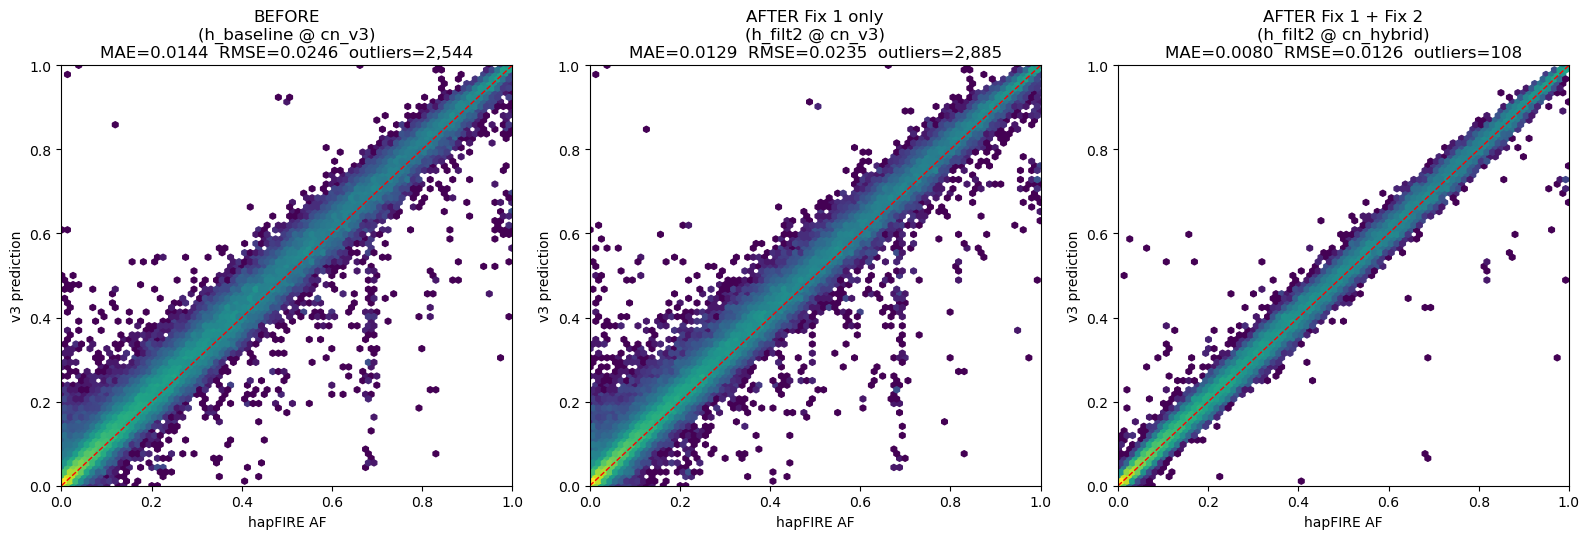

BEFORE                            MAE 0.0144  RMSE 0.0246  outliers 2,544
Fix 1 only (filt2 h)              MAE 0.0129  RMSE 0.0235  outliers 2,885
Fix 1 + Fix 2 stacked             MAE 0.0080  RMSE 0.0126  outliers 108


In [5]:
assert founders == v3_founders_full, 'h founder order != cn_var founder order'

# Predictions on the matched SNP set
pred_orig       = h_baseline @ v3_gt_match     # BEFORE
pred_filt2_only = h_filt2    @ v3_gt_match     # Fix 1 only
pred_both       = h_filt2    @ cn_hybrid       # Fix 1 + Fix 2

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
for ax, pred, title in [
    (axes[0], pred_orig,       'BEFORE\n(h_baseline @ cn_v3)'),
    (axes[1], pred_filt2_only, 'AFTER Fix 1 only\n(h_filt2 @ cn_v3)'),
    (axes[2], pred_both,       'AFTER Fix 1 + Fix 2\n(h_filt2 @ cn_hybrid)'),
]:
    err   = np.abs(pred - hf_af_loc)
    mae   = err.mean()
    rmse  = (err**2).mean()**0.5
    n_out = int((err > 0.1).sum())
    ax.hexbin(hf_af_loc, pred, gridsize=80, cmap='viridis', mincnt=1, bins='log')
    ax.plot([0,1],[0,1],'r--',lw=1)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel('hapFIRE AF')
    ax.set_ylabel('v3 prediction')
    ax.set_title(f'{title}\nMAE={mae:.4f}  RMSE={rmse:.4f}  outliers={n_out:,}')
plt.tight_layout()
plt.show()

def stats(p, label):
    e = np.abs(p - hf_af_loc)
    print(f'{label:32s}  MAE {e.mean():.4f}  RMSE {((p-hf_af_loc)**2).mean()**0.5:.4f}  outliers {int((e>0.1).sum()):,}')
stats(pred_orig,       'BEFORE')
stats(pred_filt2_only, 'Fix 1 only (filt2 h)')
stats(pred_both,       'Fix 1 + Fix 2 stacked')


### What to look for

If Fix 1 (filt2) **alone** is mostly an h-bias fix, the middle panel should look very similar to the BEFORE panel — the per-SNP outliers should largely remain because they live in `cn_var`, not in `h`. The third panel adds Fix 2 on top, which is what actually clears the off-diagonal mass.

If the middle panel shows a meaningful reduction in outlier count, that would imply some of the per-SNP outliers were also being driven by the h-vector bias (i.e. cactus founders over-weighted). The MAE/RMSE/outlier numbers under each panel quantify this.